# 1. Импорты и конфигурация

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('metrics', exist_ok=True)

FIGURES = 'figures'
METRICS = 'metrics'

TEST_DAYS = 30
SHIFT = 4
N_FEATURES = 10

print("Конфигурация загружена")

Конфигурация загружена


# 2. Загрузка данных

In [27]:
import requests, io

GITHUB_RAW_URL = 'https://raw.githubusercontent.com/dmikib/covid19-xai/refs/heads/main/data/processed/dataset_final.csv'

response = requests.get(GITHUB_RAW_URL)
df = pd.read_csv(io.StringIO(response.text), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Период: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"\nКолонки:\n{list(df.columns)}")

Датасет: 653 строк, 32 столбцов
Период: 2021-01-01 — 2022-10-15

Колонки:
['Unnamed: 0', 'date', 'new_cases', 'new_cases_smoothed', 'new_tests', 'positive_rate', 'stringency_index', 'humidity', 'precipitation', 'windspeed', 'temperature', 'retail_mobility', 'transit_mobility', 'workplaces_mobility', 'residential_mobility', 'new_cases_smooth', 'omicron_wave', 'gt_covid_symptoms', 'gt_loss_of_smell', 'gt_loss_of_taste', 'gt_fever', 'gt_cough', 'gt_pcr_test', 'gt_pcr_take', 'gt_antigen_test', 'gt_hospitalization', 'gt_hospital', 'gt_vaccine', 'gt_vaccination', 'gt_self_isolation', 'gt_lockdown', 'gt_qr_code']


# 3. Определение признаков

In [28]:
TARGET = 'new_cases_smooth'

FEATURE_COLS_CANDIDATES = [
    'new_tests', 'positive_rate', 'stringency_index',
    'humidity', 'precipitation', 'windspeed', 'temperature',
    'retail_mobility', 'transit_mobility', 'workplaces_mobility', 'residential_mobility',
    'gt_covid_symptoms', 'gt_loss_of_smell', 'gt_loss_of_taste',
    'gt_fever', 'gt_cough', 'gt_pcr_test', 'gt_hospitalization',
    'omicron_wave',   # ← внешний флаг штамма
]

FEATURE_COLS = [c for c in FEATURE_COLS_CANDIDATES if c in df.columns]
print(f"Доступных признаков: {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"  • {f}")

Доступных признаков: 19
  • new_tests
  • positive_rate
  • stringency_index
  • humidity
  • precipitation
  • windspeed
  • temperature
  • retail_mobility
  • transit_mobility
  • workplaces_mobility
  • residential_mobility
  • gt_covid_symptoms
  • gt_loss_of_smell
  • gt_loss_of_taste
  • gt_fever
  • gt_cough
  • gt_pcr_test
  • gt_hospitalization
  • omicron_wave


# 4. Сдвиг признаков и очистка

In [29]:
df_model = df[['date', TARGET] + FEATURE_COLS].copy()

# Сдвигаем внешние признаки на SHIFT дней (симулируем реальный прогноз)
for col in FEATURE_COLS:
    df_model[col] = df_model[col].shift(SHIFT)

df_model = df_model.ffill().bfill()
df_model = df_model.dropna().reset_index(drop=True)

print(f"После обработки: {df_model.shape[0]} строк")
print(f"Итого признаков: {len(FEATURE_COLS)} (только внешние)")

После обработки: 653 строк
Итого признаков: 19 (только внешние)


# 5. Train/Test Split


In [30]:
test_df  = df_model.tail(TEST_DAYS).reset_index(drop=True)
train_df = df_model.iloc[:-TEST_DAYS].reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET].values

print(f"Train: {len(train_df)} дней  ({train_df['date'].min().date()} — {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} дней  ({test_df['date'].min().date()} — {test_df['date'].max().date()})")

Train: 623 дней  (2021-01-01 — 2022-09-15)
Test:  30 дней  (2022-09-16 — 2022-10-15)


# 6. Feature Selection (RFE)

In [31]:
# RFE использует общий пул признаков (включая лаги)
X_train_all = train_df[FEATURE_COLS].values
y_train_all = train_df[TARGET].values

rfe = RFE(estimator=LinearRegression(), n_features_to_select=N_FEATURES)
rfe.fit(X_train_all, y_train_all)

selected = [col for col, sup in zip(FEATURE_COLS, rfe.support_) if sup]
print(f"RFE отобрал {N_FEATURES} признаков:")
for f in selected:
    print(f"  ✓ {f}")

X_train_sel = X_train_all[:, rfe.support_]
X_test_sel  = test_df[FEATURE_COLS].values[:, rfe.support_]

RFE отобрал 10 признаков:
  ✓ positive_rate
  ✓ windspeed
  ✓ retail_mobility
  ✓ transit_mobility
  ✓ workplaces_mobility
  ✓ residential_mobility
  ✓ gt_covid_symptoms
  ✓ gt_loss_of_smell
  ✓ gt_loss_of_taste
  ✓ omicron_wave


# 7. Train Size Reduction

Оптимальный размер train: 450 дней  (RMSE = 23550.96)


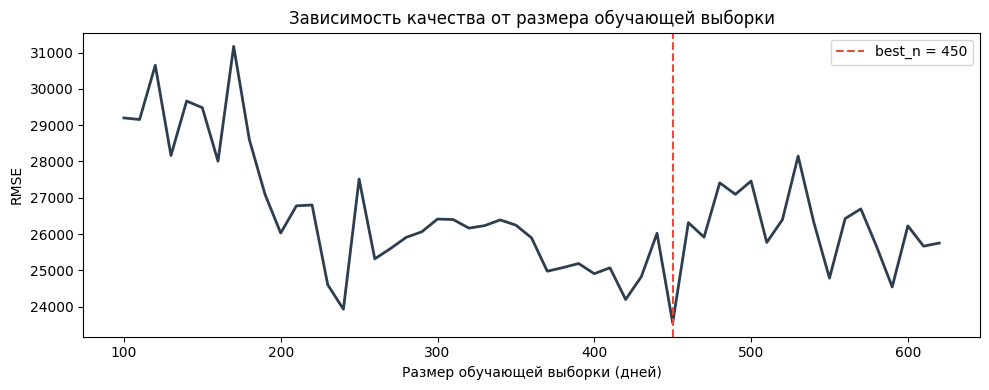

In [32]:
sizes = list(range(100, len(train_df), 10))
rmse_scores = []

xgb_ref = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                        subsample=0.8, random_state=42, verbosity=0)

for n in sizes:
    X_tr = X_train_sel[-n:]
    y_tr = y_train[-n:]
    xgb_ref.fit(X_tr, y_tr)
    pred = xgb_ref.predict(X_test_sel)
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, pred)))

best_n = sizes[np.argmin(rmse_scores)]
print(f"Оптимальный размер train: {best_n} дней  (RMSE = {min(rmse_scores):.2f})")

# График
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sizes, rmse_scores, color='#2c3e50', linewidth=2)
ax.axvline(best_n, color='#e74c3c', linestyle='--', label=f'best_n = {best_n}')
ax.set_xlabel('Размер обучающей выборки (дней)')
ax.set_ylabel('RMSE')
ax.set_title('Зависимость качества от размера обучающей выборки')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/03_train_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Обучение моделей

In [33]:
X_tr_final = X_train_sel[-best_n:]
y_tr_final = y_train[-best_n:]

# Linear Regression
lr = LinearRegression()
lr.fit(X_tr_final, y_tr_final)
lr_pred = lr.predict(X_test_sel)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr_final, y_tr_final)
rf_pred = rf.predict(X_test_sel)

# XGBoost
xgb = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_tr_final, y_tr_final)
xgb_pred = xgb.predict(X_test_sel)

print("Модели обучены")

Модели обучены


# 9. Метрики

In [34]:
def compute_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE%': round(mape, 2)}

metrics_df = pd.DataFrame([
    compute_metrics(y_test, lr_pred,  'Linear Regression'),
    compute_metrics(y_test, rf_pred,  'Random Forest'),
    compute_metrics(y_test, xgb_pred, 'XGBoost'),
])

print(metrics_df.to_string(index=False))
metrics_df.to_csv(f'{METRICS}/03_multivariate_metrics.csv', index=False)

            Model     RMSE      MAE  MAPE%
Linear Regression 32944.08 32458.27  76.10
    Random Forest 26782.25 25368.78  60.47
          XGBoost 23657.96 22692.10  54.87


# 10. График прогноза

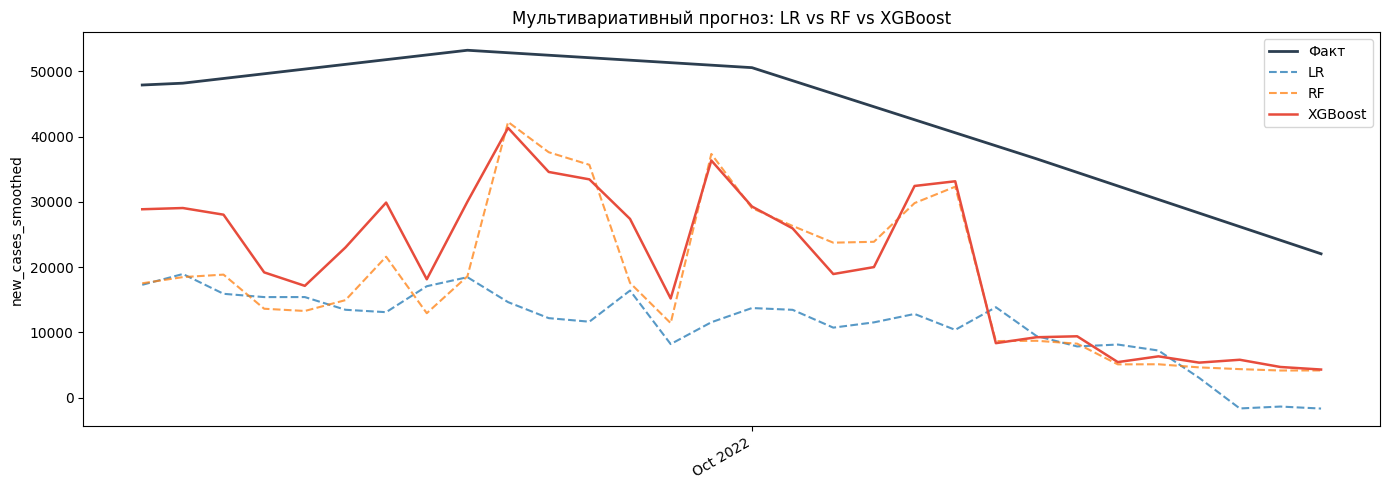

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['date'], y_test,   label='Факт',    color='#2c3e50', linewidth=2)
ax.plot(test_df['date'], lr_pred,  label='LR',      linestyle='--', alpha=0.75)
ax.plot(test_df['date'], rf_pred,  label='RF',      linestyle='--', alpha=0.75)
ax.plot(test_df['date'], xgb_pred, label='XGBoost', color='#e74c3c', linewidth=1.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('new_cases_smoothed')
ax.set_title('Мультивариативный прогноз: LR vs RF vs XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/03_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Bar chart метрик

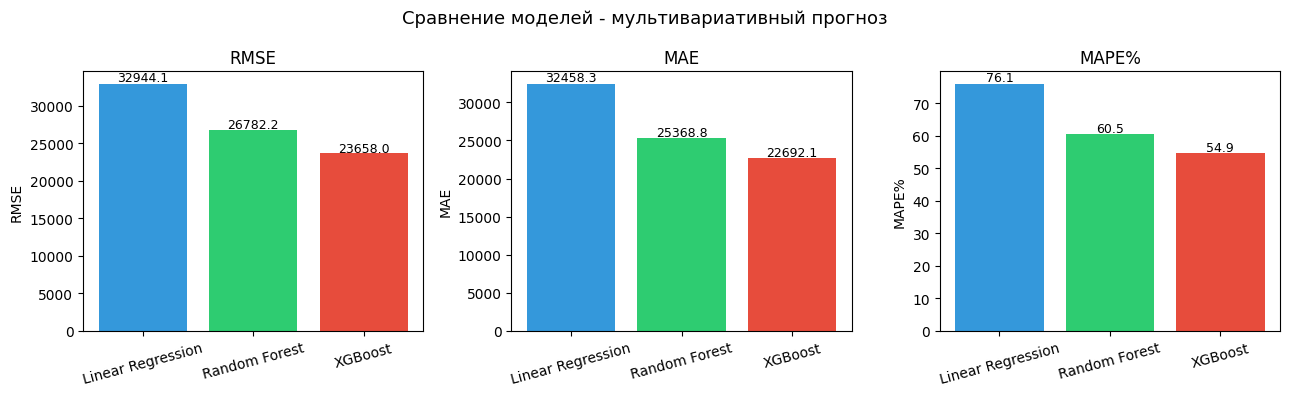

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c']
models = metrics_df['Model'].tolist()

for i, metric in enumerate(['RMSE', 'MAE', 'MAPE%']):
    vals = metrics_df[metric].tolist()
    axes[i].bar(models, vals, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(vals):
        axes[i].text(j, v * 1.01, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('Сравнение моделей - мультивариативный прогноз', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}/03_multivariate_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. Feature Importance (XGBoost)

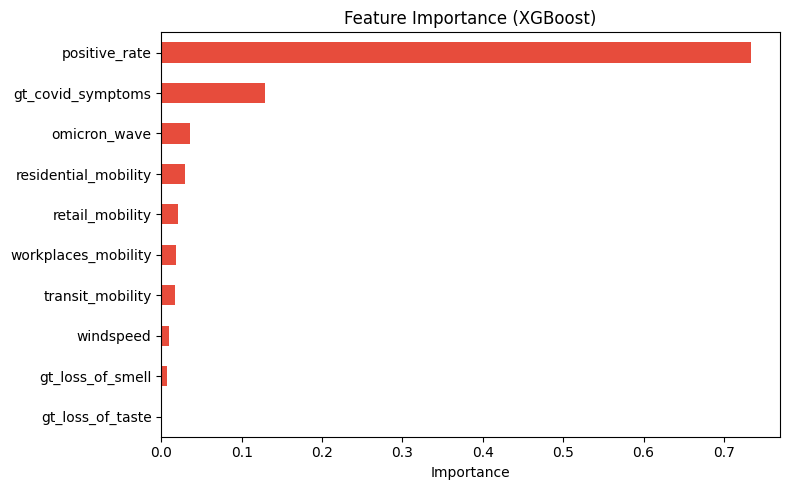

In [37]:
feat_imp = pd.Series(xgb.feature_importances_, index=selected).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Feature Importance (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{FIGURES}/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()